In [11]:
!pip install rasterio

In [12]:
import rasterio
import numpy as np
import os
import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt
from tqdm import tqdm  
from sklearn.model_selection import GridSearchCV,cross_val_score,train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.pipeline import make_pipeline


## Exploration 

In [13]:

def load_image_and_mask(image_path, mask_path):
    with rasterio.open(image_path) as img_src:
        image = img_src.read()  # (4, H, W)

    with rasterio.open(mask_path) as mask_src:
        mask = mask_src.read()  # (1, H, W)

    image = np.transpose(image, (1, 2, 0))  # (H, W, 4)
    mask = mask[0, :, :]                    # (H, W)

    return image, mask

def per_band_minmax(img):
    img = img.astype(np.float32)
    for b in range(img.shape[2]):
        band = img[:, :, b]
        img[:, :, b] = (band - band.min()) / (band.max() - band.min() + 1e-6)
    return img

def plot_image_and_mask(image, mask):
    # Ensure mask is binary (1 or 0)
    mask = (mask > 0).astype(int)

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 3, 1)
    plt.imshow(image[:, :, :3])  # show RGB
    plt.title("RGB Image")
    plt.subplot(1, 3, 2)
    plt.imshow(image[:, :, 3])  # show infrared
    plt.title("Infrared Image")
    plt.subplot(1, 3, 3)
    plt.imshow(mask, cmap='gray')  # show binary mask
    plt.title("Cloud Mask")
    plt.show()

In [14]:
def read_and_plot(id):
    image_path = f"/kaggle/input/cloud-masking-dataset/content/train/data/{id}.tif"
    mask_path = f"/kaggle/input/cloud-masking-dataset/content/train/masks/{id}.tif"
    return image_path, mask_path

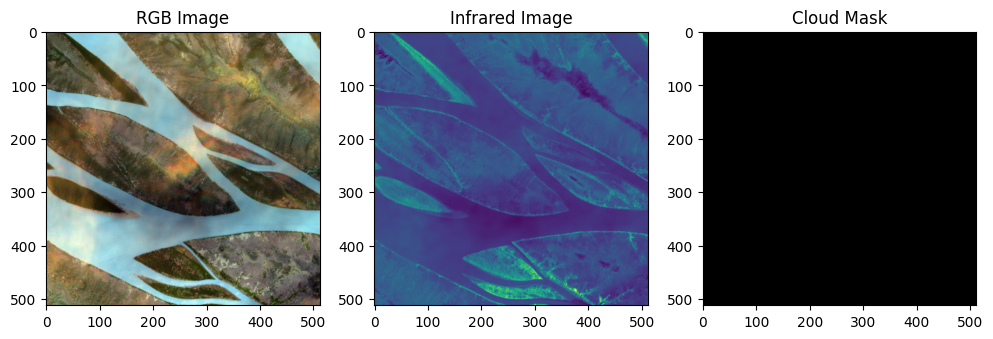

array([0], dtype=uint8)

In [15]:
# Path to your .tif file

image_path, mask_path = read_and_plot(157701)
# Open the TIFF
image , mask = load_image_and_mask(image_path, mask_path)
image = per_band_minmax(image)

plot_image_and_mask(image, mask)
np.unique( mask)

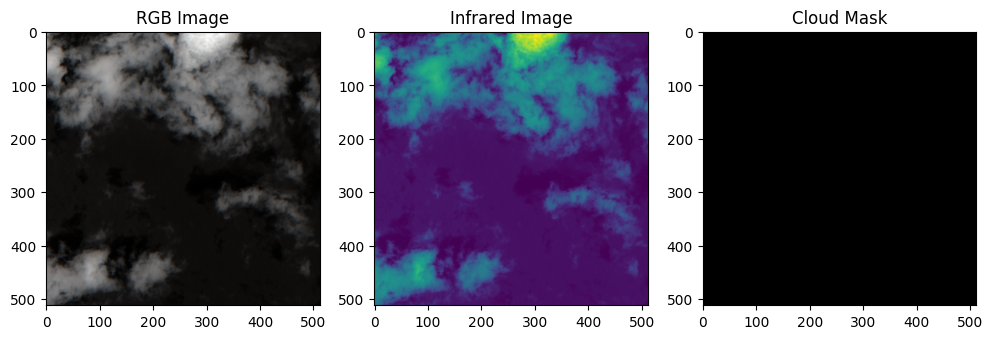

array([0], dtype=uint8)

In [16]:
# Path to your .tif file

image_path, mask_path = read_and_plot(523808)
# Open the TIFF
image , mask = load_image_and_mask(image_path, mask_path)
image = per_band_minmax(image)
plot_image_and_mask(image, mask)
np.unique( mask)

In [17]:
images_to_remove = {
    '187657.tif', '792232.tif', '726258.tif',
    "608768.tif",
    "738635.tif",
    "120337.tif",
    "204721.tif",
    "531589.tif",
    "872882.tif",
    "385959.tif",
    "873048.tif",
    "700534.tif",
    "104326.tif",
    "311740.tif",
    "567636.tif",
    "694587.tif",
    "262602.tif",
    "796353.tif",
    "715870.tif",
    "730421.tif",
    "831514.tif",
    "355671.tif",
    "102973.tif",
    "986486.tif",
    "157105.tif",
    "333752.tif",
    "294760.tif",
    "165308.tif",
    "523808.tif",
    "517885.tif",
    "684482.tif",
    "220936.tif",
    "103883.tif",
    "340927.tif",
    "220031.tif",
    "585242.tif",
    "233470.tif",
    "956360.tif",
    "749468.tif",
    "805477.tif",
    "485548.tif",
    "891662.tif",
    "103402.tif" ,
    "646313.tif",
    "880360.tif",
    "291134.tif",
    "999876.tif",
    "327408.tif",
    "343962.tif",
    "936223.tif",
    "412856.tif",
    "843596.tif",
    "171789.tif",
    "541314.tif",
    "602248.tif",
    "962529.tif",
    "726495.tif",
    "998435.tif",
    "546157.tif",
    "163182.tif",
    "938742.tif",
    "606957.tif",
    "400692.tif",
    "699573.tif",
    "760021.tif",
    "984642.tif",
    "196126.tif",
    "533121.tif",
    "938373.tif",
    "979727.tif",
    "898867.tif",
    "799565.tif",
    "556379.tif",
    "573039.tif",
    "213000.tif",
    "407618.tif",
    "961186.tif",
    "574760.tif",
    "673167.tif",
    "611945.tif",
    "310647.tif",
    "452457.tif",
    "439498.tif",
    "319869.tif",
    "223481.tif",
    "874668.tif",
    "953740.tif",
    "476018.tif",
    "369836.tif",
    "577538.tif",
    "502460.tif",
    "385166.tif",
    "976303.tif",
    "207241.tif",
    "892170.tif",
    "622669.tif",
    "325595.tif",
    "950155.tif",
    "220020.tif",
    "774225.tif",
    "867180.tif",
    "288128.tif",
    "757386.tif",
    "710434.tif",
    "628027.tif",
    "469954.tif",
    "131064.tif",
    "236435.tif",
    "588533.tif",
    "299836.tif",
    "162823.tif",
    "280222.tif",
    "742818.tif",
    "434132.tif",
    "356639.tif",
    "286044.tif",
    "243423.tif",
    "329448.tif",
    "140163.tif",
    "726667.tif",
    "766738.tif",
    "130726.tif",
    "437477.tif",
    "308535.tif",
    "289430.tif",
    "106892.tif",
    "469412.tif",
    "381770.tif",
    "992649.tif",
    "751924.tif",
    "585854.tif",
    "272117.tif",
    "472932.tif",
    "348237.tif",
    "744718.tif",
    "690462.tif",
    "542372.tif",
    "639111.tif",
    "946335.tif",
    "979988.tif",
    "933456.tif",
    "690180.tif",
    "251631.tif",
    "390120.tif",
    "616780.tif",
    "805668.tif",
    "824233.tif",
    "892313.tif",
    "505910.tif",
    "235047.tif",
    "550513.tif",
    "278852.tif",
    "504630.tif",
    "185569.tif",
    "704238.tif",
    "888939.tif",
    "721826.tif",
    "989173.tif",
    "539486.tif",
    "811451.tif",
    "824233.tif" ,
    "556379.tif",
    "951211.tif",
    "718115.tif",
    "113390.tif",
    "531641.tif",
    "398910.tif",
    "382154.tif",
    "988811.tif",
    "262934.tif",
    "843793.tif",
    "977340.tif",
    "541315.tif",
    "229204.tif",
    "195656.tif",
    "475565.tif",
    "160718.tif",
    "946561.tif",
    "534303.tif",
    "728958.tif",
    "508548.tif",
    "698717.tif",
    "501312.tif",
    "278190.tif",
    "972496.tif",
    "312616.tif",
    "356150.tif",
    "153035.tif",
    "725550.tif",
    "218152.tif",
    "804758.tif",
    "963274.tif",
    "717265.tif",
    "947438.tif",
    "992083.tif",
    "631297.tif",
    "181247.tif",
    "736130.tif",
    "155419.tif",
    "962367.tif",
    "769983.tif",
    "570852.tif",
    "523533.tif",
    "262029.tif",
    "191884.tif",
    "720148.tif",
    "688215.tif",
    "757629.tif",
    "157216.tif",
    "820861.tif",
    "558737.tif",
    "581206.tif",
    "848831.tif",
    "321494.tif",
    "888047.tif",
    "259097.tif",
    "884616.tif",
    "949178.tif",
    "406461.tif",
    "413118.tif",
    "407823.tif",
    "243132.tif",
    "363626.tif",
    "471136.tif",
    "185168.tif",
    "275868.tif",
    "705991.tif",
    "233533.tif",
    "640659.tif",
    "250840.tif",
    "529161.tif",
    "134697.tif",
    "739008.tif",
    "827744.tif",
    "452058.tif",
    "856379.tif",
    "297064.tif",
    "673172.tif",
    "766563.tif",
    "504048.tif",
    "720970.tif",
    "101657.tif",
    "694229.tif",
    "888669.tif",
    "579995.tif",
    "533377.tif",
    "261771.tif",
    "859340.tif",
    "863934.tif",
    "567574.tif",
    "961574.tif",
    "727983.tif",
    "738584.tif",
    "276214.tif",
    "850435.tif",
    "251668.tif",
    "828449.tif",
    "636561.tif",
    "767578.tif",
    "614426.tif",
    "463541.tif",
    "934794.tif",
    "715895.tif",
    "926236.tif",
    "468154.tif",
    "264631.tif",
    "211636.tif",
    "136346.tif",
    "168652.tif",
    "600318.tif",
    "607259.tif",
    "868020.tif",
    "389340.tif",
    "225200.tif",
    "906325.tif",
    "483545.tif",
    "225701.tif",
    "679720.tif",
    "275715.tif",
    "245824.tif",
    "735988.tif",
    "298561.tif",
    "963245.tif",
    "839883.tif",
}


In [18]:
len(images_to_remove)

282

## Deep learing

In [19]:
import os
from torch.utils.data import Dataset,DataLoader,random_split
from PIL import Image
import numpy as np
import torch
import torchvision.transforms as T
from collections import defaultdict
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim import lr_scheduler
import time
torch.manual_seed(27)  

In [20]:
transform = T.Compose([
    T.Resize((256, 256)),
#    T.ColorJitter(brightness=0.5, contrast=0.5),
 #   T.RandomHorizontalFlip(),
  #  T.RandomVerticalFlip(),
   # T.RandomRotation(30),
    #T.ToTensor()
])


In [21]:
class SegmentationDataset(Dataset):
    def __init__(self, image_dir, mask_dir, transform=None):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.transform = transform
        self.image_filenames = [
            f for f in os.listdir(image_dir) if f.endswith(".tiff") or f.endswith(".tif") and not f in images_to_remove
        ]

    def __len__(self):
        return len(self.image_filenames)

    def __getitem__(self, idx):
        img_name = self.image_filenames[idx]
        img_path = os.path.join(self.image_dir, img_name)
        mask_path = os.path.join(self.mask_dir, img_name)

        with rasterio.open(img_path) as img_src:
            image = img_src.read([1, 2, 3, 4])  # Read bands 1-4
        with rasterio.open(mask_path) as mask_src:
            mask = mask_src.read(1)  # Read first band

        image = per_band_minmax(image)

        image = torch.from_numpy(image).float()  # (4, 512, 512)
        mask = torch.from_numpy(mask).unsqueeze(0).float()  # (1, 512, 512)
        mask = (mask > 0.5)  # Binary mask


        if self.transform:
            image = self.transform(image)
            mask = T.Resize(image.shape[1:])(mask)


        return image, mask,img_name

In [22]:
dataset = SegmentationDataset(
    image_dir="/kaggle/input/cloud-masking-dataset/content/train/data",
    mask_dir="/kaggle/input/cloud-masking-dataset/content/train/masks",
    transform=transform
)

In [23]:
train_size = int(0.8 * len(dataset))
val_size = int(0.1 * len(dataset))
test_size =len(dataset)-train_size-val_size
len(dataset)

10291

In [24]:
train_dataset, val_dataset, test_dataset = random_split(dataset, [train_size, val_size, test_size])

# Create DataLoaders
batch_size = 8
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=True)
full_data_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

In [25]:
np.unique(val_dataset[0][1])

array([False,  True])

In [26]:
inputs, labels,_ = next(iter(train_loader))
print(f"Batch input shape: {inputs.shape}")  # Expected: [8, 4, 256, 256]
print(f"Batch label shape: {labels.shape}")

Batch input shape: torch.Size([8, 4, 256, 256])
Batch label shape: torch.Size([8, 1, 256, 256])


In [27]:
def dice_loss(pred, target, smooth=1e-6):
    pred = pred.contiguous()
    target = target.contiguous()

    intersection = (pred * target).sum(dim=(2, 3))
    union = pred.sum(dim=(2, 3)) + target.sum(dim=(2, 3))

    dice = (2. * intersection + smooth) / (union + smooth)
    dice_loss = 1 - dice.mean()

    return dice_loss

def calc_loss(pred, target, metrics, bce_weight=0.5):
    # Binary cross-entropy loss
    bce = F.binary_cross_entropy_with_logits(pred, target)

    # Apply sigmoid to pred for Dice and IoU losses
    pred_sigmoid = torch.sigmoid(pred)

    # Compute Dice and IoU losses
    dice = dice_loss(pred_sigmoid, target)

    # Combined loss
    loss = bce * bce_weight + dice * (1 - bce_weight)

    # Update metrics
    metrics['bce'] += bce.item()
    metrics['dice'] += dice.item() 
    metrics['loss'] += loss.item() 
    return loss

In [28]:
class ConvBlock(nn.Module):
    """
    A double convolutional block with batch normalization and ReLU activation.

    This block consists of two consecutive 3x3 convolutions, each followed by
    batch normalization and ReLU activation. Weights are initialized using
    Kaiming normal initialization for convolutions and constant initialization
    for batch norm layers.

    Parameters
    ----------
    in_channels : int
        Number of input channels.
    out_channels : int
        Number of output channels.

    Attributes
    ----------
    double_conv : nn.Sequential
        The sequential container holding the double convolution layers with
        batch norm and activations.

    Methods
    -------
    forward(x)
        Forward pass of the block.
    _init_weights()
        Initializes weights for convolutional and batch norm layers.
    """

    def __init__(self, in_channels, out_channels):
        super(ConvBlock, self).__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )
        self._init_weights()

    def _init_weights(self):
        """
        Initialize weights using Kaiming normal for conv layers and constants for batch norm.
        """
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, nonlinearity="relu")
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        """
        Forward pass through the double convolution block.

        Parameters
        ----------
        x : torch.Tensor
            Input tensor of shape (batch_size, in_channels, height, width).

        Returns
        -------
        torch.Tensor
            Output tensor of shape (batch_size, out_channels, height, width).
        """
        return self.double_conv(x)


class UNetPlusPlus(nn.Module):
    """
    Implementation of UNet++ (Nested UNet) architecture for image segmentation.

    This architecture features nested and dense skip connections between encoder
    and decoder paths, improving gradient flow and feature propagation compared
    to standard UNet. Supports deep supervision for multi-level outputs.

    Parameters
    ----------
    in_channels : int, optional
        Number of input channels (default: 4).
    out_channels : int, optional
        Number of output channels/classes (default: 1).
    feature_channels : list[int], optional
        Number of channels at each encoder level (default: [32, 64, 128, 256, 512]).
    deep_supervision : bool, optional
        Whether to enable deep supervision (output at multiple decoder levels)
        (default: False).

    Attributes
    ----------
    encX_0 : ConvBlock
        Encoder blocks where X is the level (0-4).
    decX_Y : ConvBlock
        Decoder blocks where X is the starting level and Y is the nesting level.
    final* : nn.Conv2d
        Final 1x1 convolution layers for output.
    maxpool : nn.MaxPool2d
        Max pooling layer for downsampling.
    up : nn.Upsample
        Upsampling layer with bilinear interpolation.

    Methods
    -------
    forward(x)
        Forward pass through the network.
    """

    def __init__(
        self,
        in_channels=4,
        out_channels=1,
        feature_channels=[32, 64, 128, 256, 512],
        deep_supervision=False,
    ):
        super(UNetPlusPlus, self).__init__()
        self.deep_supervision = deep_supervision

        # Encoder
        self.enc0_0 = ConvBlock(in_channels, feature_channels[0])
        self.enc1_0 = ConvBlock(feature_channels[0], feature_channels[1])
        self.enc2_0 = ConvBlock(feature_channels[1], feature_channels[2])
        self.enc3_0 = ConvBlock(feature_channels[2], feature_channels[3])
        self.enc4_0 = ConvBlock(feature_channels[3], feature_channels[4])

        # Decoder blocks (nested skip connections)
        self.dec0_1 = ConvBlock(
            feature_channels[0] + feature_channels[1], feature_channels[0]
        )
        self.dec1_1 = ConvBlock(
            feature_channels[1] + feature_channels[2], feature_channels[1]
        )
        self.dec2_1 = ConvBlock(
            feature_channels[2] + feature_channels[3], feature_channels[2]
        )
        self.dec3_1 = ConvBlock(
            feature_channels[3] + feature_channels[4], feature_channels[3]
        )

        self.dec0_2 = ConvBlock(
            feature_channels[0] * 2 + feature_channels[1], feature_channels[0]
        )
        self.dec1_2 = ConvBlock(
            feature_channels[1] * 2 + feature_channels[2], feature_channels[1]
        )
        self.dec2_2 = ConvBlock(
            feature_channels[2] * 2 + feature_channels[3], feature_channels[2]
        )

        self.dec0_3 = ConvBlock(
            feature_channels[0] * 3 + feature_channels[1], feature_channels[0]
        )
        self.dec1_3 = ConvBlock(
            feature_channels[1] * 3 + feature_channels[2], feature_channels[1]
        )

        self.dec0_4 = ConvBlock(
            feature_channels[0] * 4 + feature_channels[1], feature_channels[0]
        )

        # Final convs for deep supervision
        if self.deep_supervision:
            self.final1 = nn.Conv2d(feature_channels[0], out_channels, kernel_size=1)
            self.final2 = nn.Conv2d(feature_channels[0], out_channels, kernel_size=1)
            self.final3 = nn.Conv2d(feature_channels[0], out_channels, kernel_size=1)
            self.final4 = nn.Conv2d(feature_channels[0], out_channels, kernel_size=1)
        else:
            self.final = nn.Conv2d(feature_channels[0], out_channels, kernel_size=1)

        self.maxpool = nn.MaxPool2d(2, 2)
        self.up = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=True)

    def forward(self, x):
        """
        Forward pass through the UNet++ network.

        Parameters
        ----------
        x : torch.Tensor
            Input tensor of shape (batch_size, in_channels, height, width).

        Returns
        -------
        torch.Tensor or list[torch.Tensor]
            - If deep_supervision=False: Single output tensor of shape
              (batch_size, out_channels, height, width)
            - If deep_supervision=True: List of output tensors from multiple
              decoder levels (shapes may vary by level)
        """
        # Encoder
        x0_0 = self.enc0_0(x)
        x1_0 = self.enc1_0(self.maxpool(x0_0))
        x2_0 = self.enc2_0(self.maxpool(x1_0))
        x3_0 = self.enc3_0(self.maxpool(x2_0))
        x4_0 = self.enc4_0(self.maxpool(x3_0))

        # Nested Decoder
        x0_1 = self.dec0_1(torch.cat([x0_0, self.up(x1_0)], dim=1))
        x1_1 = self.dec1_1(torch.cat([x1_0, self.up(x2_0)], dim=1))
        x2_1 = self.dec2_1(torch.cat([x2_0, self.up(x3_0)], dim=1))
        x3_1 = self.dec3_1(torch.cat([x3_0, self.up(x4_0)], dim=1))

        x0_2 = self.dec0_2(torch.cat([x0_0, x0_1, self.up(x1_1)], dim=1))
        x1_2 = self.dec1_2(torch.cat([x1_0, x1_1, self.up(x2_1)], dim=1))
        x2_2 = self.dec2_2(torch.cat([x2_0, x2_1, self.up(x3_1)], dim=1))

        x0_3 = self.dec0_3(torch.cat([x0_0, x0_1, x0_2, self.up(x1_2)], dim=1))
        x1_3 = self.dec1_3(torch.cat([x1_0, x1_1, x1_2, self.up(x2_2)], dim=1))

        x0_4 = self.dec0_4(torch.cat([x0_0, x0_1, x0_2, x0_3, self.up(x1_3)], dim=1))

        # Output
        if self.deep_supervision:
            out1 = self.final1(x0_1)
            out2 = self.final2(x0_2)
            out3 = self.final3(x0_3)
            out4 = self.final4(x0_4)
            return [
                out1,
                out2,
                out3,
                out4,
            ]  # You can average these later or apply custom loss
        else:
            return self.final(x0_4)


In [29]:
torch.cuda.is_available()

True

In [30]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

model = UNetPlusPlus(deep_supervision=False).to(device)

optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=3,min_lr=1e-6)

In [31]:
def train_model(model, train_loader, val_loader, optimizer, scheduler, num_epochs=10):
    best_loss = float("inf")
    
    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 10)

        start_time = time.time()

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            epoch_metrics = {
                'loss': 0.0,
                'bce': 0.0,
                'dice': 0.0,
            }
            samples_processed = 0
            dataloader = train_loader if phase == 'train' else val_loader

            for inputs, masks, _ in dataloader: 
                inputs = inputs.to(device)
                masks = masks.to(device).float()

                # Zero gradients
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    # Forward pass
                    outputs = model(inputs)
                    
                    # Calculate loss and metrics
                    batch_metrics = defaultdict(float)
                    loss = calc_loss(outputs, masks, batch_metrics)

                    # Backward pass + optimize only if in training phase
                    if phase == 'train':
                        loss.backward()
                        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                        optimizer.step()

                # Update epoch metrics
                batch_size = inputs.size(0)
                samples_processed += batch_size
                for key in epoch_metrics:
                    epoch_metrics[key] += batch_metrics[key] * batch_size

            # Calculate epoch-level metrics
            epoch_loss = epoch_metrics['loss'] / samples_processed
            epoch_bce = epoch_metrics['bce'] / samples_processed
            epoch_dice = epoch_metrics['dice'] / samples_processed

            # Print metrics
            print(f'{phase.capitalize()} Metrics:')
            print(f'Loss: {epoch_loss:.4f} | BCE: {epoch_bce:.4f} | Dice: {epoch_dice:.4f}')
            print()

            if phase == 'val':
                if epoch_loss < best_loss:
                    print(f'Validation loss improved from {best_loss:.4f} to {epoch_loss:.4f}')
                    best_loss = epoch_loss
                    torch.save(model.state_dict(), 'best_model.pth')
            
                if scheduler is not None:
                    if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                        scheduler.step(epoch_loss)


        # Calculate epoch time
        epoch_time = time.time() - start_time
        print(f'Epoch time: {epoch_time // 60:.0f}m {epoch_time % 60:.0f}s\n')

    print(f'Training complete. Best validation loss: {best_loss:.4f}')
    return model

In [42]:
# from collections import defaultdict
# import time
# import torch

# def train_model(model, train_loader, val_loader, optimizer, scheduler, num_epochs=10):
#     best_loss = float("inf")
    
#     for epoch in range(num_epochs):
#         print(f'Epoch {epoch+1}/{num_epochs}')
#         print('-' * 10)

#         start_time = time.time()

#         for phase in ['train', 'val']:
#             model.train() if phase == 'train' else model.eval()

#             epoch_metrics = {
#                 'loss': 0.0,
#                 'bce': 0.0,
#                 'dice': 0.0,
#             }
#             samples_processed = 0
#             dataloader = train_loader if phase == 'train' else val_loader

#             for inputs, masks, _ in dataloader: 
#                 inputs = inputs.to(device)
#                 masks = masks.to(device).float()

#                 optimizer.zero_grad()

#                 with torch.set_grad_enabled(phase == 'train'):
#                     outputs = model(inputs)

#                     # Deep supervision support: multiple outputs
#                     if isinstance(outputs, list):
#                         loss = 0
#                         batch_metrics = defaultdict(float)
#                         for out in outputs:
#                             temp_metrics = defaultdict(float)
#                             loss += calc_loss(out, masks, temp_metrics)
#                             for k, v in temp_metrics.items():
#                                 batch_metrics[k] += v
#                         loss /= len(outputs)
#                         for k in batch_metrics:
#                             batch_metrics[k] /= len(outputs)
#                     else:
#                         batch_metrics = defaultdict(float)
#                         loss = calc_loss(outputs, masks, batch_metrics)

#                     if phase == 'train':
#                         loss.backward()
#                         torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
#                         optimizer.step()

#                 batch_size = inputs.size(0)
#                 samples_processed += batch_size
#                 for key in epoch_metrics:
#                     epoch_metrics[key] += batch_metrics[key] * batch_size

#             epoch_loss = epoch_metrics['loss'] / samples_processed
#             epoch_bce = epoch_metrics['bce'] / samples_processed
#             epoch_dice = epoch_metrics['dice'] / samples_processed

#             print(f'{phase.capitalize()} Metrics:')
#             print(f'Loss: {epoch_loss:.4f} | BCE: {epoch_bce:.4f} | Dice: {epoch_dice:.4f}')
#             print()

#             if phase == 'val':
#                 if epoch_loss < best_loss:
#                     print(f'Validation loss improved from {best_loss:.4f} to {epoch_loss:.4f}')
#                     best_loss = epoch_loss
#                     torch.save(model.state_dict(), 'best_model.pth')
            
#                 if scheduler is not None:
#                     if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
#                         scheduler.step(epoch_loss)

#         epoch_time = time.time() - start_time
#         print(f'Epoch time: {epoch_time // 60:.0f}m {epoch_time % 60:.0f}s\n')

#     print(f'Training complete. Best validation loss: {best_loss:.4f}')
#     return model

In [ ]:
trained_model = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    scheduler=scheduler,
    num_epochs=25
)

Epoch 1/35
----------


# Explore with model

In [32]:
def evaluate_and_collect(model, dataloader, device):
    model.eval()
    results = []
    
    def vectorized_iou(pred, target):
        # Input shapes: (B, 1, H, W) for both tensors
        pred = pred.bool()
        target = target.bool()
        intersection = (pred & target).float().sum(dim=(2, 3)) 
        union = (pred | target).float().sum(dim=(2, 3))       
        return (intersection + 1e-6) / (union + 1e-6)          # (B, 1)
    def vectorized_dice(pred, target):
        # Input shapes: (B, 1, H, W) for both tensors
        pred = pred.bool()
        target = target.bool()
        intersection = (pred & target).float().sum(dim=(2, 3))
        pred_sum = pred.float().sum(dim=(2, 3))
        target_sum = target.float().sum(dim=(2, 3))
        dice = (2 * intersection + 1e-6) / (pred_sum + target_sum + 1e-6)
        return dice  # (B, 1)
    with torch.no_grad():
        for inputs, labels, filenames in tqdm(dataloader, desc="Processing Batches"):
            inputs = inputs.to(device)
            labels = labels.to(device).float()   # Ensure float type
            # Forward pass
            outputs = model(inputs)
            preds = (torch.sigmoid(outputs) > 0.5)  # (B, 1, H, W)
            
            # Add channel dimension if missing (B, H, W) -> (B, 1, H, W)
            if labels.ndim == 3:
                labels = labels.unsqueeze(1)
            
            # Batch-wise IoU calculation
            batch_ious = vectorized_dice(preds, labels).squeeze(1)  # (B,)
            
            # Process each sample
            for i in range(inputs.size(0)):
                results.append({
                    'input': inputs[i].cpu().float(),
                    'label': labels[i].cpu().numpy().squeeze().astype(np.uint8),
                    'pred': preds[i].cpu().numpy().squeeze().astype(np.uint8),
                    'iou': batch_ious[i].item(),
                    'filename': filenames[i]
                })

    return sorted(results, key=lambda x: x['iou'])
    
def show_worst_predictions(results, k=5):
    for i, result in enumerate(results[:k]):
        input_img = result['input'].permute(1, 2, 0).numpy()
        input_img = (input_img - input_img.min()) / (input_img.max() - input_img.min())  # Normalize for display
        label_mask = result['label']
        pred_mask = result['pred']
        iou = result['iou']
        filename = result['filename']

        # Print unique values for true mask and predicted mask
        unique_true = np.unique(label_mask)
        unique_pred = np.unique(pred_mask)



        # Plot the images
        plt.figure(figsize=(12, 4))
        plt.suptitle(f"{filename} | Worst-{i+1} | IoU: {iou:.4f}")

        plt.subplot(1, 3, 1)
        plt.imshow(input_img)
        plt.title("Input Image")

        plt.subplot(1, 3, 2)
        plt.imshow(label_mask, cmap='gray')
        plt.title("Ground Truth")

        plt.subplot(1, 3, 3)
        plt.imshow(pred_mask, cmap='gray')
        plt.title("Prediction")

        plt.show()
        print(f"Unique values for {filename}:")
        print(f"Ground Truth Mask (True): {unique_true}")
        print(f"Prediction Mask (Pred): {unique_pred}")


In [33]:
# Load the best model weights
model.load_state_dict(torch.load("/kaggle/input/25epoch/pytorch/default/1/best_model (4).pth"))
#model.load_state_dict(torch.load("/kaggle/input/25epoch/pytorch/default/1/best_model (4).pth"))

/tmp/ipykernel_31/3266440675.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("/kaggle/input/25epoch/pytorch/default/1/best_model (4).pth

<All keys matched successfully>

In [71]:
worst_results = evaluate_and_collect(model, full_data_loader, device)

Processing Batches: 100%|██████████| 1287/1287 [18:52<00:00,  1.14it/s]


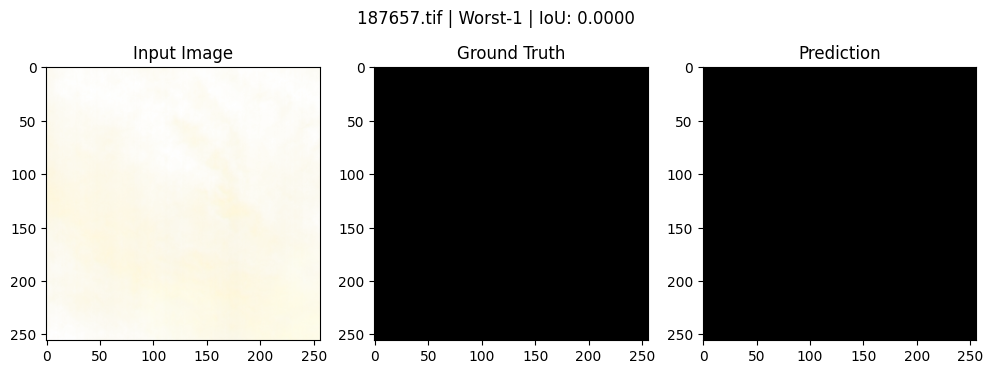

Unique values for 187657.tif:
Ground Truth Mask (True): [1]
Prediction Mask (Pred): [0]


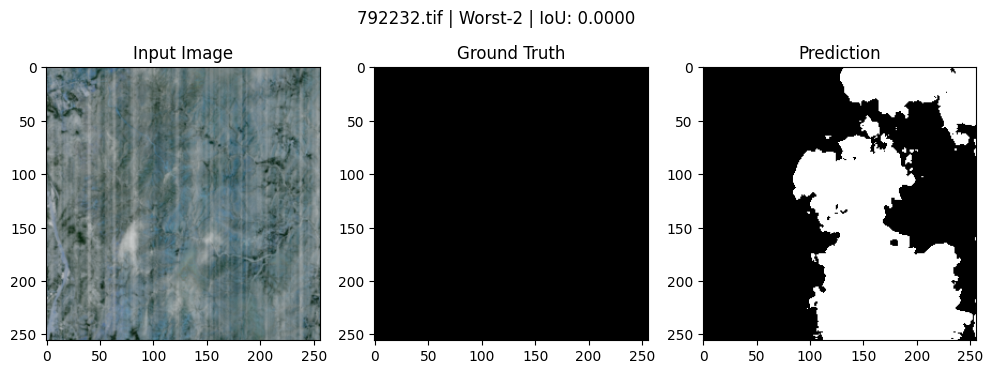

Unique values for 792232.tif:
Ground Truth Mask (True): [0]
Prediction Mask (Pred): [0 1]


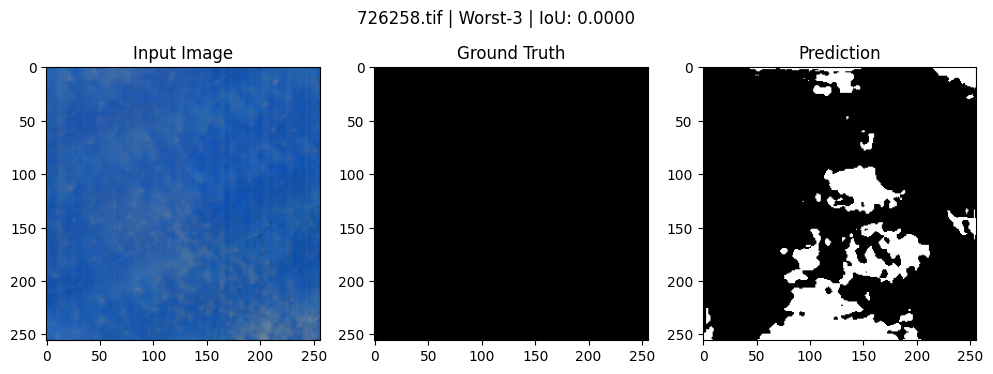

Unique values for 726258.tif:
Ground Truth Mask (True): [0]
Prediction Mask (Pred): [0 1]


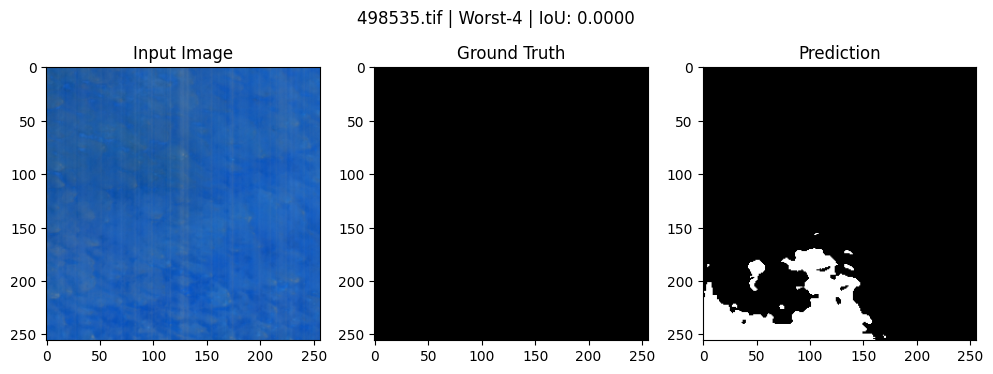

Unique values for 498535.tif:
Ground Truth Mask (True): [0]
Prediction Mask (Pred): [0 1]


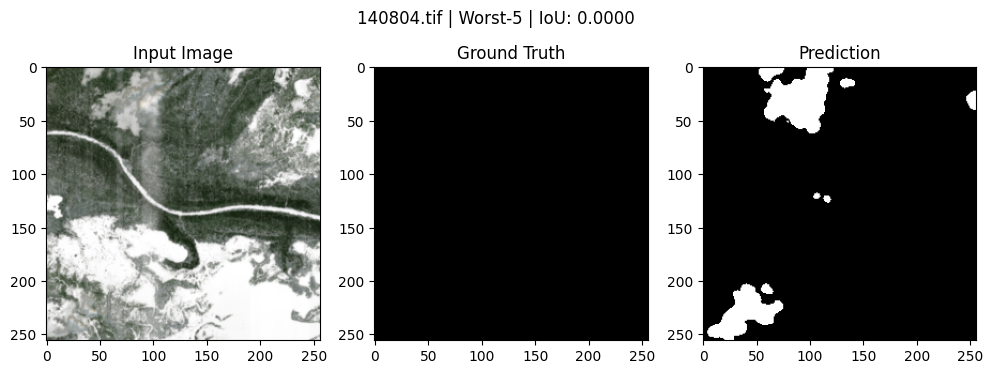

Unique values for 140804.tif:
Ground Truth Mask (True): [0]
Prediction Mask (Pred): [0 1]


In [74]:
show_worst_predictions(worst_results, k=5)

## MissLabeled images name

In [72]:
def get_result_by_filename(results, target_filename):
    """Find and return the result dictionary for a specific filename"""
    for result in results:
        if result['filename'] == target_filename:
            return result
    return None  # If not found

In [73]:
# Get the list of filenames where IoU = 0
threshold = 1e-10
zero_iou_filenames = [result['filename'] for result in worst_results if result['iou'] <= threshold]
#898867
# Print the list
print(zero_iou_filenames)
len(zero_iou_filenames)

['187657.tif', '792232.tif', '726258.tif']


3

## Accuracy

In [34]:
from tqdm import tqdm

def evaluate_dice_score(model, dataloader, device):
    model.eval()
    total_dice = 0.0
    total_samples = 0

    with torch.no_grad():
        # Wrap dataloader with tqdm for progress bar
        for inputs, targets, _ in tqdm(dataloader, desc="Evaluating", total=len(dataloader)):
            inputs = inputs.to(device)
            targets = targets.to(device)
            # Forward pass
            outputs = model(inputs)
            preds = (torch.sigmoid(outputs) > 0.5).float()

            # Compute dice loss and convert to score
            dice = 1 - dice_loss(preds, targets).item()

            # Accumulate metrics
            batch_size = inputs.size(0)
            total_dice += dice * batch_size
            total_samples += batch_size

    # Compute average Dice score
    avg_dice = total_dice / total_samples
    print(f"Dice Score (Accuracy): {avg_dice:.4f}")
    return avg_dice

In [35]:
from torch.utils.data import ConcatDataset, DataLoader

combined_dataset = ConcatDataset([val_loader.dataset, test_loader.dataset])
combined_loader = DataLoader(combined_dataset, batch_size=test_loader.batch_size, shuffle=False, num_workers=4)


In [38]:
dice_score = evaluate_dice_score(model, full_data_loader, device)
dice_score

Evaluating: 100%|██████████| 1287/1287 [20:47<00:00,  1.03it/s]

Dice Score (Accuracy): 0.9174


0.91736814730972

In [76]:
torch.save(model, "full_model.pth")

## RlE encoding

In [78]:
import numpy as np
def rle_encode(mask):
    """
    Encodes a binary mask using Run-Length Encoding (RLE).
    
    Args:
        mask (np.ndarray): 2D binary mask (0s and 1s).
    
    Returns:
        str: RLE-encoded string.
    """
    pixels = mask.flatten(order='F')  # Flatten in column-major order
    pixels = np.concatenate([[0], pixels, [0]])  # Add padding to detect transitions
    runs = np.where(pixels[1:] != pixels[:-1])[0] + 1  # Get transition indices
    runs[1::2] -= runs[::2]  # Compute run lengths
    runs[::2] -= 1  # Make it 0-indexed instead of 1-indexed

    return " ".join(map(str, runs))  # Convert to string format


def create_rle_dataframe(data_loader):
    """
    Creates a pandas DataFrame from a DataLoader containing image IDs and RLE-encoded masks.
    
    Args:
        data_loader (DataLoader): PyTorch DataLoader yielding (image, mask, img_name) tuples.
    
    Returns:
        pd.DataFrame: DataFrame with columns 'id' (image filename without extension) and
                      'segmentation' (RLE-encoded mask string).
    """
    ids = []
    segmentations = []
    
    # Define resize transform to ensure 512x512 masks
    #resize = T.Resize((512, 512), interpolation=T.InterpolationMode.NEAREST)
    
    # Wrap data_loader with tqdm for progress bar
    for _, mask, img_name in tqdm(data_loader, desc="Processing masks"):
        # Handle batched data
        for i in range(mask.size(0)):  # Iterate over batch dimension
            # Extract single mask and ensure it's binary
            single_mask = mask[i]  # Shape: (1, H, W)
            #single_mask = resize(single_mask)  # Resize to 512x512
            single_mask = single_mask.squeeze(0)  # Remove channel dimension: (512, 512)
            single_mask = (single_mask > 0.5).float()  # Ensure binary (0s and 1s)
            
            # Convert to NumPy for RLE encoding
            mask_np = single_mask.cpu().numpy().astype(np.uint8)
            
            # Encode mask as RLE
            rle_string = rle_encode(mask_np)
            
            # Extract image ID from filename (remove extension)
            img_id = os.path.splitext(img_name[i])[0]
            
            # Append to lists
            ids.append(img_id)
            segmentations.append(rle_string)
    
    # Create DataFrame
    df = pd.DataFrame({
        'id': ids,
        'segmentation': segmentations
    })
    
    return df

def create_predicted_rle_dataframe(model, data_loader, device="cuda" if torch.cuda.is_available() else "cpu"):
    """
    Creates a pandas DataFrame with predicted mask RLEs from a model and DataLoader.
    
    Args:
        model (nn.Module): Trained PyTorch model (e.g., UNetPlusPlus) for segmentation.
        data_loader (DataLoader): DataLoader yielding (image, mask, img_name) tuples.
        device (str or torch.device): Device to run the model on (e.g., 'cuda' or 'cpu').
    
    Returns:
        pd.DataFrame: DataFrame with columns 'id' (image filename without extension) and
                      'segmentation' (RLE-encoded predicted mask string).
    """
    model.eval()  # Set model to evaluation mode
    model.to(device)  # Move model to the specified device
    
    ids = []
    segmentations = []
    
    # Define resize transform to ensure 512x512 masks
    #resize = T.Resize((512, 512), interpolation=T.InterpolationMode.NEAREST)
    
    with torch.no_grad():  # Disable gradient computation for inference
        # Wrap data_loader with tqdm for progress bar
        for image, _, img_name in tqdm(data_loader, desc="Generating predictions"):
            # Move images to device
            image = image.to(device)
            
            # Get model predictions
            pred = model(image)  # Shape: (batch_size, 1, H, W) or similar
            pred = torch.sigmoid(pred)  # Convert logits to probabilities
            pred = (pred > 0.5).float()  # Binarize predictions
            
            # Process each prediction in the batch
            for i in range(pred.size(0)):
                # Extract single predicted mask
                single_pred = pred[i]  # Shape: (1, H, W)
                #single_pred = resize(single_pred)  # Resize to 512x512
                single_pred = single_pred.squeeze(0)  # Shape: (512, 512)
                
                # Convert to NumPy for RLE encoding
                pred_np = single_pred.cpu().numpy().astype(np.uint8)
                
                # Encode predicted mask as RLE
                rle_string = rle_encode(pred_np)
                
                # Extract image ID from filename (remove extension)
                img_id = os.path.splitext(img_name[i])[0]
                
                # Append to lists
                ids.append(img_id)
                segmentations.append(rle_string)
    
    # Create DataFrame
    df = pd.DataFrame({
        'id': ids,
        'segmentation': segmentations
    })
    
    return df

In [79]:
class ParticipantVisibleError(Exception):
    # If you want an error message to be shown to participants, you must raise the error as a ParticipantVisibleError
    # All other errors will only be shown to the competition host. This helps prevent unintentional leakage of solution data.
    pass


def rle_decode(mask_rle: str, shape=(256, 256)) -> np.ndarray:
    """Decodes an RLE-encoded string into a binary mask with validation checks."""
    
    if not isinstance(mask_rle, str) or not mask_rle.strip() or mask_rle.lower() == 'nan':
        # Return all-zero mask if RLE is empty, invalid, or NaN
        return np.zeros(shape, dtype=np.uint8)
    
    try:
        s = list(map(int, mask_rle.split()))
    except:
        raise ParticipantVisibleError("RLE segmentation must contain only integers")
    
    if len(s) % 2 != 0:
        raise ParticipantVisibleError("RLE segmentation must have even-length (start, length) pairs")
    
    if any(x < 0 for x in s):
        raise ParticipantVisibleError("RLE segmentation must not contain negative values")
    
    mask = np.zeros(shape[0] * shape[1], dtype=np.uint8)
    starts, lengths = s[0::2], s[1::2]
    
    for start, length in zip(starts, lengths):
        if start >= mask.size or start + length > mask.size:
            raise ParticipantVisibleError("RLE indices exceed image size")
        mask[start:start + length] = 1
    
    return mask.reshape(shape, order='F')  # Convert to column-major order

def dice_coefficient(mask1: np.ndarray, mask2: np.ndarray) -> float:
    """Computes the Dice coefficient between two binary masks."""
    intersection = np.sum(mask1 * mask2)
    return (2.0 * intersection + 1e-7) / (np.sum(mask1) + np.sum(mask2) + 1e-7)  # Avoid division by zero

def score(solution: pd.DataFrame, submission: pd.DataFrame, row_id_column_name: str) -> float:
    """Computes the Dice score between solution and submission."""
    
    # Check if required columns exist
    required_columns = {row_id_column_name, "segmentation"}
    if not required_columns.issubset(solution.columns) or not required_columns.issubset(submission.columns):
        raise ParticipantVisibleError("Solution and submission must contain 'id' and 'segmentation' columns")
    
    # Ensure the IDs match between solution and submission
    if not solution[row_id_column_name].equals(submission[row_id_column_name]):
        raise ParticipantVisibleError("Submission IDs do not match solution IDs")
    
    # Delete the row ID column as Kaggle aligns solution and submission before passing to score()
    del solution[row_id_column_name]
    del submission[row_id_column_name]
    
    # Decode RLE masks and compute Dice score
    dice_scores = []
    for solution_seg, submission_seg in zip(solution["segmentation"], submission["segmentation"]):
        solution_mask = rle_decode(solution_seg)
        submission_mask = rle_decode(submission_seg)
        dice_scores.append(dice_coefficient(solution_mask, submission_mask))
    
    return np.mean(dice_scores)


In [80]:
submission = create_predicted_rle_dataframe(model,test_loader)


Generating predictions: 100%|██████████| 129/129 [01:04<00:00,  2.01it/s]


In [81]:
solution = create_rle_dataframe(test_loader)
solution

Processing masks: 100%|██████████| 129/129 [00:44<00:00,  2.92it/s]


,id,segmentation
0,552760,0 65536
1,326956,0 30683 30687 251 30953 239 31212 236 31471 23...
2,146853,78 39 206 17 334 40 462 16 591 39 719 12 848 2...
3,354085,0 65536
4,208529,0 15681 15686 249 15944 234 16179 8 16206 224 ...
...,...,...
1025,817870,0 77 143 33 256 78 397 37 512 79 651 42 768 80...
1026,199868,236 20 492 20 748 20 1004 20 1260 20 1517 19 1...
1027,676510,39 20 248 8 294 21 504 8 549 22 761 7 805 22 1...
1028,276470,0 48 51 252 307 250 563 249 819 248 1076 246 1...


In [82]:
solution=solution.sort_values(by='id').reset_index()
submission=submission.sort_values(by='id').reset_index()

In [83]:
solution=solution.drop(columns=["index"])

In [84]:
submission=submission.drop(columns=["index"])

In [85]:
score_value = score( solution, submission, row_id_column_name='id')

In [86]:
score_value

0.9195344585176892